<a href="https://colab.research.google.com/github/SebastianGarncarek/California-Housing-Prediction/blob/main/CaliHousePredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting housing prices in California

Author: Sebastian Garncarek

In this project, we'll try to estimate the value of houses in California the best we can, using methods learned during the course. The data is comprised of summary stats about houses found in a given California district based on the 1990 census data.

## Importing the data set and an overview

In [1]:
import pandas as pd
import os
import kagglehub

# Downloading latest version
path=kagglehub.dataset_download("camnugent/california-housing-prices")

full_path = os.path.join(path, 'housing.csv')

# Loading the data frame
caliData = pd.read_csv(full_path)

# Checking the data
print("Size of data:", caliData.shape)
display(caliData.head())

caliData.info()

display(caliData.isnull().sum())

print(caliData.describe())


100%|██████████| 400k/400k [00:00<00:00, 649kB/s]

Extracting files...
Size of data: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

There are a few things that we can notice:
1. Column 'total_bedrooms' has 207 missing entries.
2. All features, aside from 'ocean_proximity' are of a float type. For some of our methods we're gonna have to transform 'ocean proximity' into numeric values.
3. Each record in the data set represents a housing block, that's why the amount of rooms, bedrooms and population seem so big. When preparing our dataset, we should transform this data into an average single household.

Let's see the distribution of the feature that we will be estimating - median value

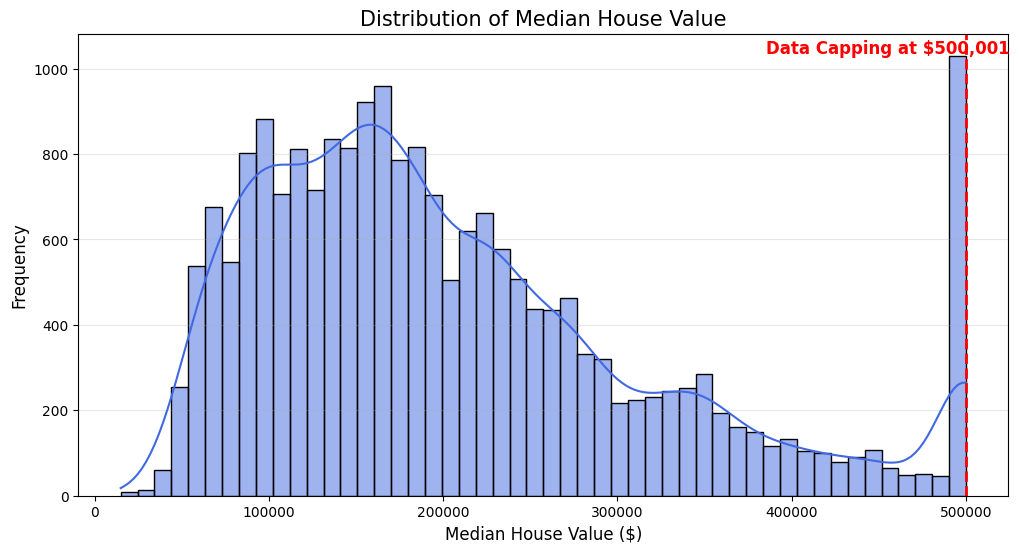

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(caliData['median_house_value'], bins=50, kde=True, color='royalblue')

plt.axvline(x=500001, color='red', linestyle='--', linewidth=2)

plt.text(385000, 1035, 'Data Capping at $500,001', color='red', fontsize=12, fontweight='bold')

plt.title('Distribution of Median House Value', fontsize=15)
plt.xlabel('Median House Value ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

Based on the histogram we can notice a serious issue with our data set - there's a massive spike around `$500,000`. Based on the rest of the values this peak seems abnormal - it may suggest that the median value was capped at that mark. Every property value above this number was recorded as `$500,001` (the maximum), regardless of its true price. This can lead to inaccurate predictions for more valuable properties, which in turn will lead to higher RMSE, as no model can learn values beyond this wall.

In [3]:
# Calculating how much data is capped
capCount = (caliData['median_house_value'] >= 500001).sum()
totalCount=len(caliData)
capPercentage=(capCount/totalCount)*100

print(f"Number of capped records ($500,001): {capCount}")
print(f"Total number of records:            {totalCount}")
print(f"Percentage of capped data:          {capPercentage:.2f}%")

Number of capped records ($500,001): 965
Total number of records:            20640
Percentage of capped data:          4.68%


The capped data constitutes about 4.7% of the whole dataset. Those records create a significant bias when it comes to regression. Since our data is distorted by an artificial constraint it may be justified to remove those observations to create a more accurate model for houses valued below $500,000. We lose some other information, but the distortions from those capped records may cause more problems.

In [4]:
# Creating a copy of the original data set without capped records
caliNoCapData=caliData[caliData['median_house_value']<500001].copy()

print(f"Original dataset size: {len(caliData)}")
print(f"Cleaned dataset size:  {len(caliNoCapData)}")
print(f"Removed records:       {len(caliData)-len(caliNoCapData)}")

Original dataset size: 20640
Cleaned dataset size:  19675
Removed records:       965


Let's showcase the statistics for our 'cleaned' data

In [5]:
print(caliNoCapData.describe())
display(caliNoCapData.isnull().sum())

          longitude      latitude  housing_median_age   total_rooms  \
count  19675.000000  19675.000000        19675.000000  19675.000000   
mean    -119.563192     35.651780           28.386277   2619.763659   
std        2.006108      2.149802           12.509113   2181.348207   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.760000     33.930000           18.000000   1438.000000   
50%     -118.500000     34.270000           28.000000   2111.000000   
75%     -117.990000     37.730000           37.000000   3120.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    19475.000000  19675.000000  19675.000000   19675.000000   
mean       539.645751   1440.812198    501.186023       3.676717   
std        422.413200   1143.648725    383.264636       1.570272   
min          2.000000      3.000000      2.000000       0.499900   
25%        297.00000

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,200
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Let's do some deeper research:
1. Let's see the correlation between the features.
2. Since we have both latitude and longitude we can make a visual map of the median value based on them and population.

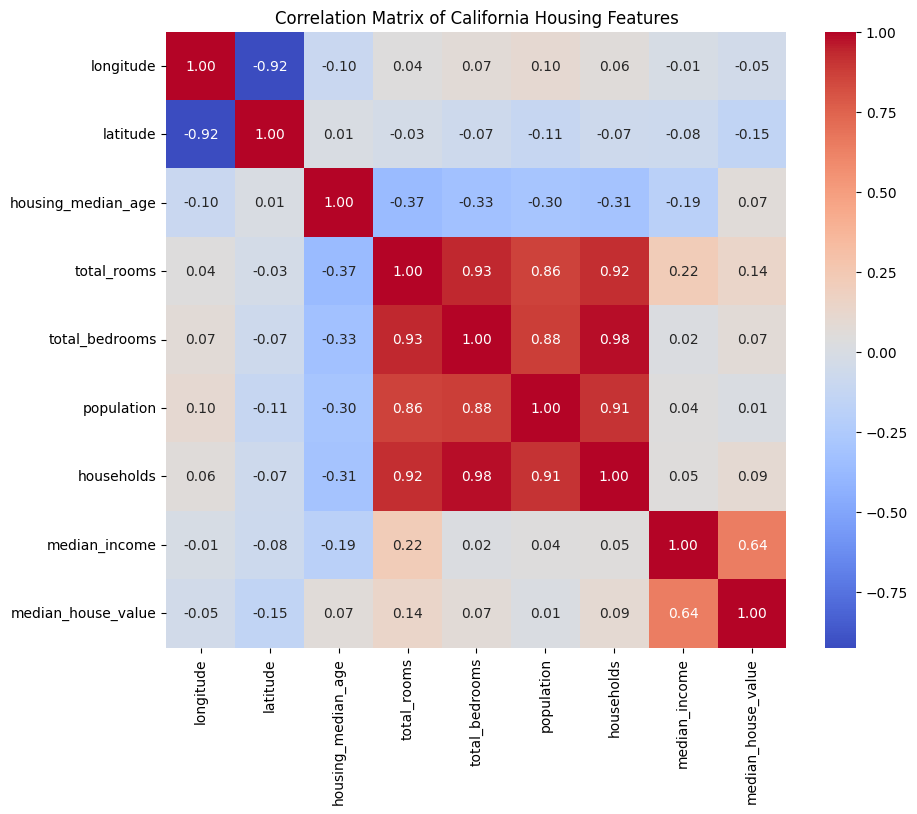

In [6]:
# Correlation Matrix Heatmap

# Selecting only numeric columns for correlation
plt.figure(figsize=(10, 8))
numericData=caliNoCapData.select_dtypes(include=['float64', 'int64'])
corrMatrix=numericData.corr()

sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of California Housing Features')
plt.show()

Based on the correlation matrix, we can draw several conclusions:
1. There is a very high correlation between features: total rooms, total bedrooms, population and households. These features describe the whole block of households instead of just one. We're gonna use these features to create new ones, correlating to one household.
2. There's high correlation between income and house value - the higher the income the more valuable are the houses. That's the most important feature when it comes to predicting the house value.

<Figure size 1000x700 with 0 Axes>

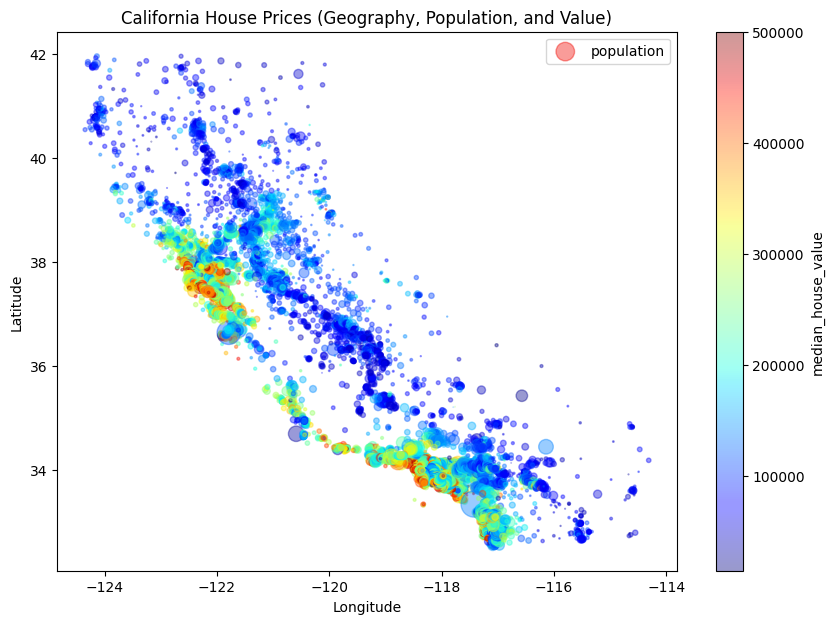

In [7]:
# Geographical Visualization

plt.figure(figsize=(10, 7))
caliNoCapData.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
        s=caliNoCapData["population"]/100, label="population", figsize=(10,7),
        c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
        sharex=False)
plt.title('California House Prices (Geography, Population, and Value)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

Based on the visualisation we can come to some conlusions:
1. The closer the household is to an ocean, the more valuable it is.
2. The more populated areas have more valuable households.

The most valuable households are in or very nearby Los Angeles (34°N 118°W) and San Francisco (38°N 122°W)

## Preparing data

By examing our dataset we have found a few areas that need some fixing to do:
1. Column "total_bedrooms" has some missing values.
2. For some of the methods we chose, there can't be categorical variables, so we need to transform 'ocean_proximity' into numerical type.
3. We wanna predict the price of one household and our dataset describes the whole blocks of households. We might wanna make some new features out of the ones we already have that will describe a sole household.

There are two main ways we can deal with missing data in the 'total_bedrooms" column:
1. Deleting the records with missing data - the easier method; the number of rows with missing data is just about 1% so we don't throw out a lot of records, but we would be missing data from other columns in these rows,
2. Imputing the missing values with median - we don't lose any information about other features, but we might get illogical records (block with a lot of rooms and small amount of bedrooms).

Imputation is a safer option, so we'll do that.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# The median will be only calculated based on the training data to avoid leakage
# Splitting the data set into training and test set
trainSet, testSet=train_test_split(caliNoCapData, test_size=0.2, random_state=0)

# Seperating the feature that's gonna be predicted from all the others
xTrain=trainSet.drop("median_house_value", axis=1)
yTrain=trainSet["median_house_value"].copy()

xTest=testSet.drop("median_house_value", axis=1)
yTest=testSet["median_house_value"].copy()

# Creating imputer with 'median' chosen as the strategy
imputer=SimpleImputer(strategy="median")

# Temporarily removing not numeric column (median cannot be calculated for categorical type)
xTrainNum=xTrain.drop("ocean_proximity", axis=1)
xTestNum=xTest.drop("ocean_proximity", axis=1)

# Imputing the median (learned only on test set) on all data
imputer.fit(xTrainNum)

xTrainNumTrans=imputer.transform(xTrainNum)
xTestNumTrans=imputer.transform(xTestNum)

# Converting back to data frame
xTrainTemp=pd.DataFrame(xTrainNumTrans, columns=xTrainNum.columns, index=xTrain.index)
xTestTemp=pd.DataFrame(xTestNumTrans, columns=xTestNum.columns, index=xTest.index)

display(xTrainTemp.isnull().sum())

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0


We've managed to fill the missing values! Right now our data set is missing the 'ocean proximity' column, but before we adapt it to our model we're going to create "new" features.

In [9]:
import numpy as np

xTrainTemp["rooms_per_household"]=xTrainTemp["total_rooms"]/xTrainTemp["households"] # Logically, the bigger the house the more valuable it is
xTrainTemp["bedrooms_per_room"]=xTrainTemp["total_bedrooms"]/xTrainTemp["total_rooms"] # Households that have a lot of bedrooms compared to other rooms may be less valuable (no spaces for other activities)
xTrainTemp["population_per_household"]=xTrainTemp["population"]/xTrainTemp["households"] # More people per household may suggest poorer areas or more family-oriented, so they may be less valuable

xTestTemp["rooms_per_household"]=xTestTemp["total_rooms"]/xTestTemp["households"]
xTestTemp["bedrooms_per_room"]=xTestTemp["total_bedrooms"]/xTestTemp["total_rooms"]
xTestTemp["population_per_household"]=xTestTemp["population"]/xTestTemp["households"]

Let's check the correlation once again - this time with addition of our new features.

IMPORTANT NOTE!
Our first correlation matrix was made using the whole data set, while this one is using only the training set. We did that to avoid leakage - to calculate the "bedrooms per room" feature, we needed to impute median. If we calculated median of the whole data set, there would be leakage. That's why we had to make this matrix only for training data.

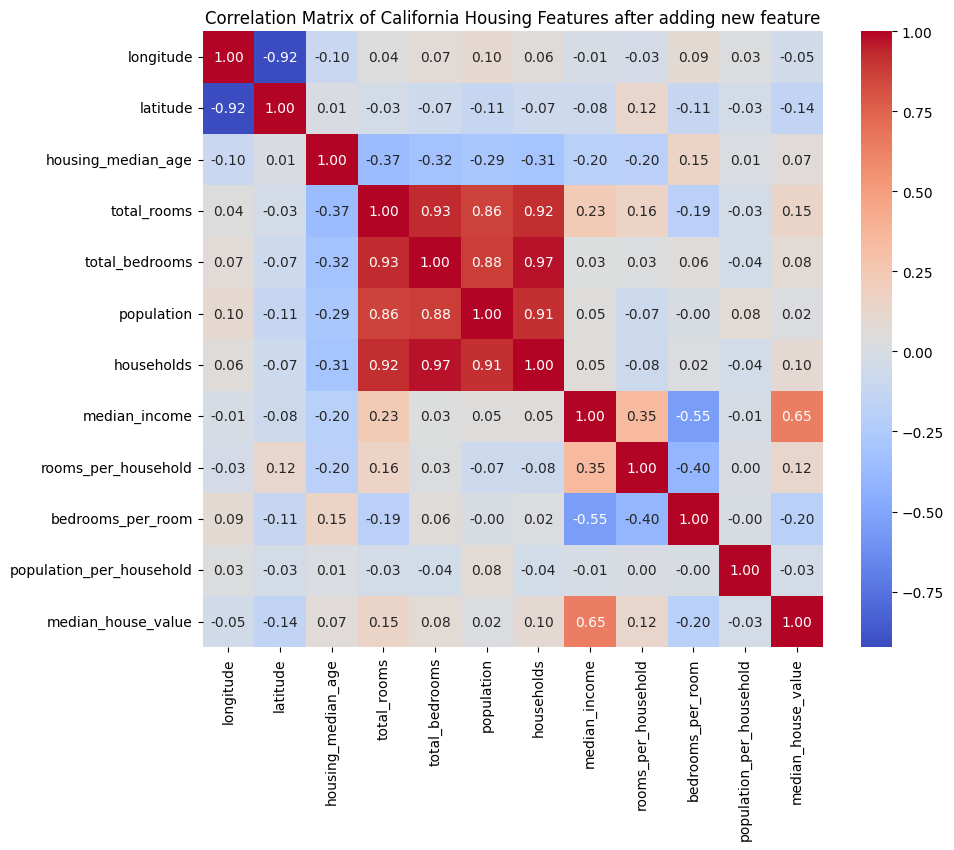

In [10]:
plt.figure(figsize=(10, 8))
trainTemp=pd.concat([xTrainTemp, yTrain], axis=1)
numericDataTemp=trainTemp.select_dtypes(include=['float64', 'int64'])
corrMatrixTemp=numericDataTemp.corr()

sns.heatmap(corrMatrixTemp, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of California Housing Features after adding new feature')
plt.show()

Our new features tell us a little bit more about what influences the house value:
1. The overall number of bedrooms had little to no influence on the value of the house, but there's a huge negative correlation between the number of bedrooms per room and the house value. Basically, the more bedrooms per room the lesser the value. (those maybe households with no living rooms, etc.)
2. The more rooms per household the more valuable the house.

In [11]:
from sklearn.preprocessing import StandardScaler

# Scaling every numeric feature
scaler=StandardScaler()
numColumns=xTrainTemp.columns # All current numeric columns

xTrainScaled=scaler.fit_transform(xTrainTemp)
xTrainScaled=pd.DataFrame(xTrainScaled,
                          columns=numColumns,
                          index=xTrainTemp.index)

xTestScaled=scaler.transform(xTestTemp)
xTestScaled=pd.DataFrame(xTestScaled,
                          columns=numColumns,
                          index=xTestTemp.index)

Now we're gonna perform one-hot encoding on the "ocean proximity" column - basically, we're gonna transform text column into binary columns.

In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

# Creating the encoded columns
trainOceanEnc=encoder.fit_transform(xTrain[["ocean_proximity"]]).toarray()
testOceanEnc=encoder.transform(xTest[["ocean_proximity"]]).toarray()

# Getting the column names (from the feature's values)
encNames=encoder.get_feature_names_out(["ocean_proximity"])

xTrainEnc=pd.DataFrame(trainOceanEnc,columns=encNames,index=xTrain.index)
xTestEnc=pd.DataFrame(testOceanEnc,columns=encNames,index=xTest.index)

xTrainFinal=pd.concat([xTrainScaled,xTrainEnc], axis=1)
xTestFinal=pd.concat([xTestScaled,xTestEnc], axis=1)

print("Final shape of training set:", xTrainFinal.shape)
print("Final shape of testing set:", xTestFinal.shape)

print("Final DataFrame head:")
display(xTrainFinal.head())

Final shape of training set: (15740, 16)
Final shape of testing set: (3935, 16)
Final DataFrame head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
776,-1.271309,0.932650,-0.029348,-0.381551,-0.541842,-0.614922,-0.583250,0.632682,0.493092,-0.637519,-0.085057,0.0,0.0,0.0,1.0,0.0
15010,1.257900,-1.345150,-0.348423,2.399031,2.667123,2.146080,2.708691,-0.371596,-0.103386,-0.086422,-0.109698,0.0,0.0,0.0,0.0,1.0
18139,-1.226412,0.792908,0.209958,0.209693,-0.028503,0.046741,0.213525,1.680288,-0.030817,-0.692254,-0.103892,1.0,0.0,0.0,0.0,0.0
3454,0.569476,-0.613832,-0.827034,1.802769,1.353930,1.775095,1.484697,1.038018,0.372988,-0.733005,0.061386,1.0,0.0,0.0,0.0,0.0
10595,0.878768,-0.911949,-0.986572,-0.283923,-0.549005,-0.542471,-0.528210,2.042104,0.616487,-0.948716,-0.063031,1.0,0.0,0.0,0.0,0.0


## Linear Regression Model

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Dropping the columns that were heavely correlated to each other - they could make errors in linear regression. There's is no big loss of information because of the created features.
dropFeatures=["total_rooms", "total_bedrooms", "population", "households"]

xTrainLin=xTrainFinal.drop(columns=[col for col in dropFeatures if col in xTrainFinal.columns])
xTestLin=xTestFinal.drop(columns=[col for col in dropFeatures if col in xTestFinal.columns])

# Creating a linear regression model
linRegModel=LinearRegression()
linRegModel.fit(xTrainLin,yTrain)

# Checking attributed weights
coefficients = pd.DataFrame(linRegModel.coef_, xTrainLin.columns, columns=['Coefficient'])
print("\nHow each feature influences the price:")
print(coefficients.sort_values(by='Coefficient', ascending=False))


How each feature influences the price:
                              Coefficient
ocean_proximity_ISLAND      142662.795676
median_income                61312.192329
bedrooms_per_room            11582.146256
housing_median_age            8679.376052
rooms_per_household           5171.804850
population_per_household     -3051.222041
ocean_proximity_NEAR OCEAN  -19756.719744
ocean_proximity_<1H OCEAN   -27597.490058
ocean_proximity_NEAR BAY    -28826.710219
latitude                    -47787.826428
longitude                   -49881.276947
ocean_proximity_INLAND      -66481.875655


We can see which features make the most change in the estimation:
1. Location seems to change the value the most - being located on an island adds over `$142,000` to the estimated value but location inland decrese the value by over `$66,000`. By examing the latitude and longitude we can also see that houses located more inland get lower values (the more northe and east the lesser value).
2. Median income had the most correlation to the house value and we can see that it really has great influence on the price.

Let's now evaluate our model.

In [14]:
trainLinPred=linRegModel.predict(xTrainLin)
trainLinRMSE=np.sqrt(mean_squared_error(yTrain, trainLinPred))

testLinPred=linRegModel.predict(xTestLin)
testLinRMSE=np.sqrt(mean_squared_error(yTest, testLinPred))

print(f"--- LINEAR REGRESSION ---")
print(f"RMSE on training set: ${trainLinRMSE:,.2f}")
print(f"RMSE on test set:     ${testLinRMSE:,.2f}")

--- LINEAR REGRESSION ---
RMSE on training set: $62,594.74
RMSE on test set:     $65,356.91


Our RMSE is quite high - it's about `$65,400` while the median value of a house is about `$192,000`. On the other hand we can see that the differenece in RMSE is small. That means there's no overfitting but the overall high RMSE shows that the linear regression model may not be complex enough for our problem.

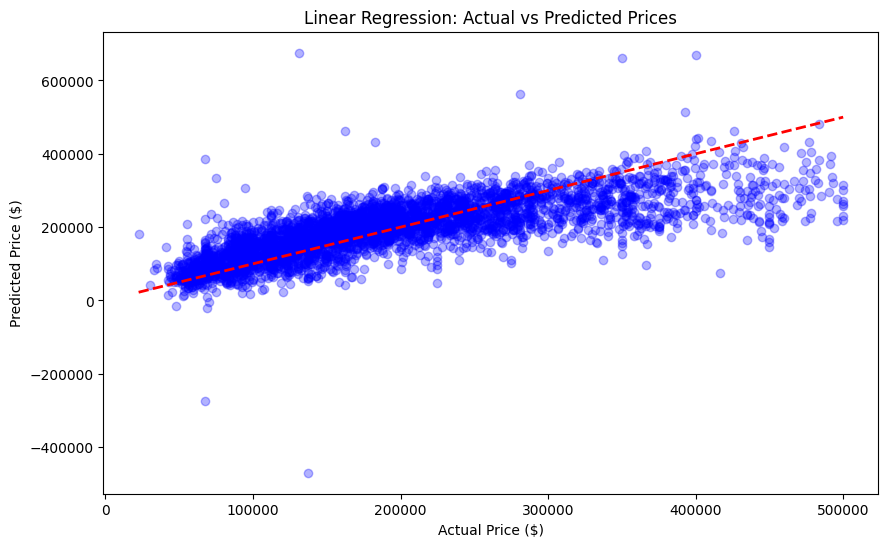

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(yTest, testLinPred, alpha=0.3, color='blue')
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], '--r', linewidth=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.show()

By plotting the actual prices and predicted prices we can see that the regression model is better at predicting lower valued houses, although in that range it also has the biggest errors (houses with predicted negative value or way too big of an estimated value). Let's try some more complex models.

## Decision Tree

In [16]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Creating a decision tree model (at first not too deep, we'll tweak the parameters further down the line)
treeReg=DecisionTreeRegressor(max_depth=5, random_state=0)
treeReg.fit(xTrainFinal, yTrain)

# Evaluating our model
treeTrainPred=treeReg.predict(xTrainFinal)
treeTrainRMSE=np.sqrt(mean_squared_error(yTrain, treeTrainPred))

treeTestPred=treeReg.predict(xTestFinal)
treeTestRMSE=np.sqrt(mean_squared_error(yTest, treeTestPred))

print(f"--- DECISION TREE REGRESSOR ---")
print(f"RMSE on training set: ${treeTrainRMSE:,.2f}")
print(f"RMSE on test set:     ${treeTestRMSE:,.2f}")

--- DECISION TREE REGRESSOR ---
RMSE on training set: $58,925.25
RMSE on test set:     $61,739.17


Let's find the best parameters for our Decision Tree model

In [17]:
from sklearn.model_selection import GridSearchCV

# Declaring the parameters we want to optimize
treeParams=[
    {
        'max_depth': [5, 8, 10, 12, 15], # Shallow trees may suffer from bias, so deeper tree might yield better results
        'min_samples_leaf': [1, 10, 20, 50], # A minimum amount of samples in leaf may help us when dealing with outliers
        'max_features': [1.0, 'sqrt'] # Maybe arbitrarily decreasing the amount of features when deciding the split will result in better predictions
    }
]

treeLearnReg=DecisionTreeRegressor(random_state=0)

# Looking for the best combination of parameters using cross validation; the cv=5 parameter means that the training set is split into 5 - 4 of those parts are used for training and the other is used for validtion. With each iteration different part is used for validation.
treeSearch=GridSearchCV(treeLearnReg, treeParams, cv=5,
                                scoring='neg_mean_squared_error',
                                return_train_score=True)

# Uncomment if you want to test the fitting function
#treeSearch.fit(xTrainFinal, yTrain)
#print(f"Best Tree Parameters: {treeSearch.best_params_}")
#treeOptReg=treeSearch.best_estimator_ # Taking the model with best parameters

We found that the best results were obtained for deeper tree, with no limits when it comes to features and with at least 20 samples in a leaf. Let's evaluate our new optimized Decision Tree model.

In [18]:
# The tree with best tested parameters (you can comment if you have already fitted the params)
treeOptReg=DecisionTreeRegressor(max_depth=15, min_samples_leaf=20, random_state=0)
treeOptReg.fit(xTrainFinal, yTrain)

treeOptTrainPred=treeOptReg.predict(xTrainFinal)
treeOptTrainRMSE=np.sqrt(mean_squared_error(yTrain, treeOptTrainPred))

treeOptTestPred=treeOptReg.predict(xTestFinal)
treeOptTestRMSE=np.sqrt(mean_squared_error(yTest, treeOptTestPred))

print(f"--- DECISION TREE REGRESSOR ---")
print(f"RMSE on training set: ${treeOptTrainRMSE:,.2f}")
print(f"RMSE on test set:     ${treeOptTestRMSE:,.2f}")

--- DECISION TREE REGRESSOR ---
RMSE on training set: $43,933.36
RMSE on test set:     $53,357.89


We've managed to optimize our decision tree, the RMSE on test set is around `$53,500` so we decreased it by over `$10,000` compared to our linear regression model. The maximum depth of our decision tree is equal to `15` and to create a leaf it needs at least `20` samples.

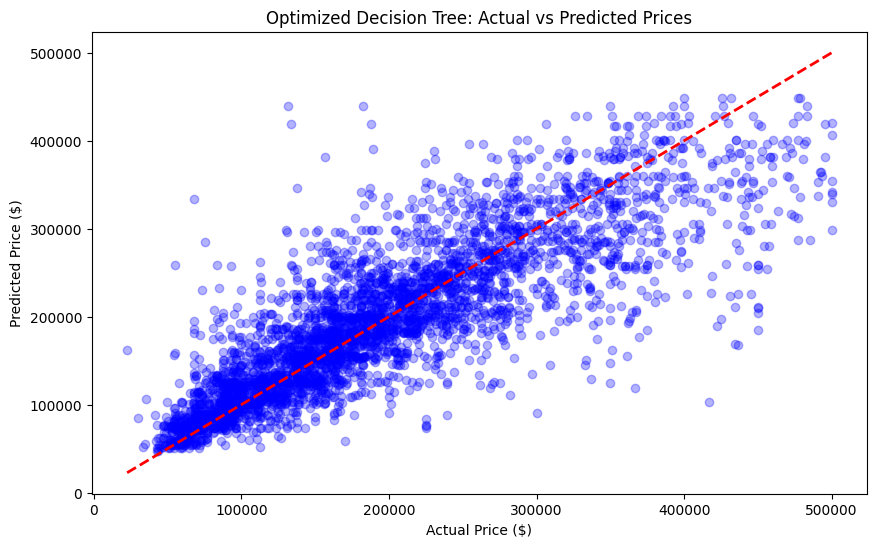

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(yTest, treeOptTestPred, alpha=0.3, color='blue')
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], '--r', linewidth=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Optimized Decision Tree: Actual vs Predicted Prices')
plt.show()

We can see that there's a lot of variance when it comes to predicted values, they are scattered all over the plot. Let's now create a model using a lot of trees to try and get a lower error.

## Random Forest

In [20]:
from sklearn.ensemble import RandomForestRegressor

# Creating first random forest with 100 trees
forestReg=RandomForestRegressor(n_estimators=100, random_state=0)

forestReg.fit(xTrainFinal, yTrain)

# Evaluating our model
forestPredTrain=forestReg.predict(xTrainFinal)
forestRmseTrain=np.sqrt(mean_squared_error(yTrain, forestPredTrain))

forestPredTest=forestReg.predict(xTestFinal)
forestRmseTest=np.sqrt(mean_squared_error(yTest, forestPredTest))

print(f"--- RANDOM FOREST REGRESSOR ---")
print(f"RMSE on training set: ${forestRmseTrain:,.2f}")
print(f"RMSE on test set:     ${forestRmseTest:,.2f}")

--- RANDOM FOREST REGRESSOR ---
RMSE on training set: $16,958.30
RMSE on test set:     $45,696.56


Because creating one random forest takes a lot of time to find the best model we're not gonna check a lot of parameters.

NOTE: It takes a significant amount of time to find those parameters so you might consider skipping upcoming cell (the optimized tree is commented in the cell after)

In [21]:
from sklearn.model_selection import GridSearchCV

forestParams=[
    {
        'n_estimators': [100, 200],
        'max_features': [1.0, 'sqrt'],
        'max_depth': [10, 20, None]
    }
]

forestLearnReg=RandomForestRegressor(random_state=0)

forestSearch=GridSearchCV(forestLearnReg, forestParams, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

# Uncomment only if you want to test the fitting function (takes quite long)
#forestSearch.fit(xTrainFinal, yTrain)
#print(f"Best parameters: {forestSearch.best_params_}")
#forestRegOpt=forestSearch.best_estimator_ # Most optimized model

We found that the best results were obtained for bigger forest, with limited features when it comes to making decisions and no limits in regards to depth of a single tree. Let's now evaluate our optimized Random Forest model.

In [22]:
# The forest with best tested parameters (you can comment if you have already fitted the params)
forestRegOpt=RandomForestRegressor(n_estimators=200, random_state=0, max_features='sqrt')
forestRegOpt.fit(xTrainFinal, yTrain)

forestOptPredTrain=forestRegOpt.predict(xTrainFinal)
forestOptRmseTrain=np.sqrt(mean_squared_error(yTrain, forestOptPredTrain))

forestOptPredTest=forestRegOpt.predict(xTestFinal)
forestOptRmseTest=np.sqrt(mean_squared_error(yTest, forestOptPredTest))

print(f"--- RANDOM FOREST REGRESSOR ---")
print(f"RMSE on training set: ${forestOptRmseTrain:,.2f}")
print(f"RMSE on test set:     ${forestOptRmseTest:,.2f}")

--- RANDOM FOREST REGRESSOR ---
RMSE on training set: $16,739.59
RMSE on test set:     $45,034.99


Using optimized Random Forest we've managed to cut over `$8,000` from RMSE in comparision to Decision Tree.

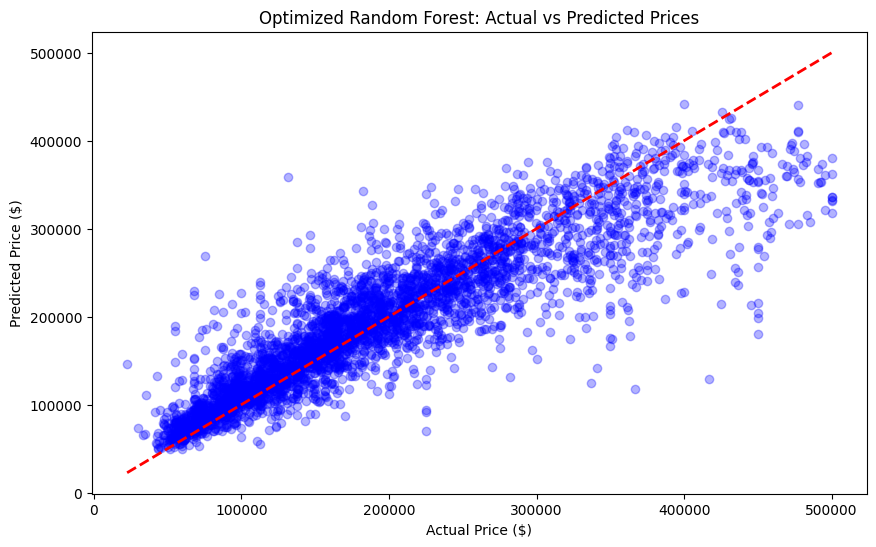

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(yTest, forestOptPredTest, alpha=0.3, color='blue')
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], '--r', linewidth=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Optimized Random Forest: Actual vs Predicted Prices')
plt.show()

The values are definitely less scattered when it comes to less valued houses, but we can see that our model still has difficulties when predicting the more pricey ones. We're gonna try to further cut the error using XGBoost.

##XGBoost

In [24]:
import xgboost as xgb

# There are many parameters to choose from, so using GridSearch would take us a long time, those parameters we
xgbReg=xgb.XGBRegressor(
    n_estimators=500,         # Because of small learining rate we wanna use more trees
    learning_rate=0.05,       # Slow learning rate ensures we won't overfit our model
    max_depth=6,              # We don't want very deep trees here to avoid overfitting
    subsample=0.8,            # When building the next tree we are not using all samples, this helps reduce the risk of overfitting - trees are more independent
    colsample_bytree=0.8,     # As above, just with columns (so, for example the most important factor in each tree won't be median income)
    random_state=0
)

# Removing characters from column names so the XGBoost Regressor can work
xTrainFinal.columns=xTrainFinal.columns.str.replace('[', '').str.replace(']', '').str.replace('<', '')
xTestFinal.columns=xTestFinal.columns.str.replace('[', '').str.replace(']', '').str.replace('<', '')

xgbReg.fit(xTrainFinal, yTrain)

xgbTrainPred=xgbReg.predict(xTrainFinal)
xgbTrainRmse=np.sqrt(mean_squared_error(yTrain, xgbTrainPred))

xgbTestPred=xgbReg.predict(xTestFinal)
xgbTestRmse=np.sqrt(mean_squared_error(yTest, xgbTestPred))

print(f"--- XGBOOST REGRESSOR ---")
print(f"RMSE on training set: ${xgbTrainRmse:,.2f}")
print(f"RMSE on test set:     ${xgbTestRmse:,.2f}")

--- XGBOOST REGRESSOR ---
RMSE on training set: $25,681.67
RMSE on test set:     $40,787.26


XGBoost managed to decrease the RMSE by almost `$5,000` when compared to our previous best model (Random Forest). Now our error is very close to `$40,000`.

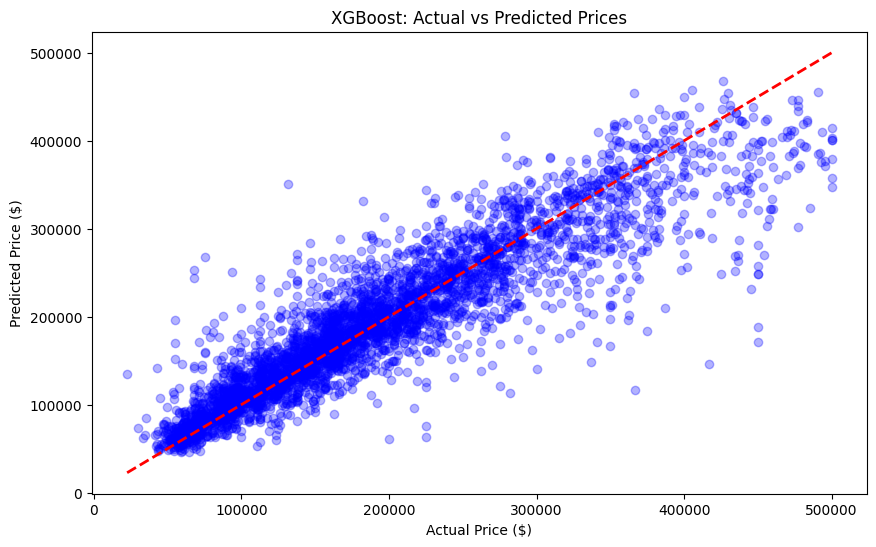

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(yTest, xgbTestPred, alpha=0.3, color='blue')
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], '--r', linewidth=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('XGBoost: Actual vs Predicted Prices')
plt.show()

Compared to Random Forest model, the prediction with more high-end houses seems to be better. Let's now move on to neural network and see how it scores compared to this model.

## Neural Network

In [26]:
from sklearn.neural_network import MLPRegressor

mlpReg=MLPRegressor(
    hidden_layer_sizes=(100, 50, 25), # we choose 3 hidden layers
    activation='relu',
    solver='adam',
    max_iter=1000, # more epochs mean more time for learning
    random_state=0,
    early_stopping=True # avoiding overfitting by checking if error on control samples decreases in consecutive iterations
)

mlpReg.fit(xTrainFinal, yTrain)

mlpTrainPred=mlpReg.predict(xTrainFinal)
mlpTrainRmse=np.sqrt(mean_squared_error(yTrain, mlpTrainPred))

mlpTestPred=mlpReg.predict(xTestFinal)
mlpTestRmse=np.sqrt(mean_squared_error(yTest, mlpTestPred))

print(f"--- NEURAL NETWORK (MLP) ---")
print(f"RMSE on training set: ${mlpTrainRmse:,.2f}")
print(f"RMSE on test set:     ${mlpTestRmse:,.2f}")

--- NEURAL NETWORK (MLP) ---
RMSE on training set: $55,291.73
RMSE on test set:     $59,536.37


We can see that our Neural Network model didn't perform as well as XGBoost or even Random Forest.

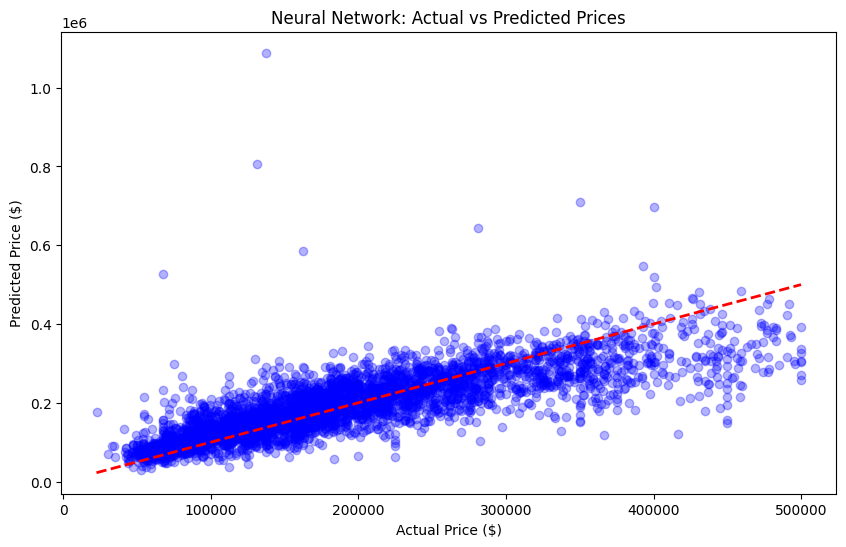

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(yTest, mlpTestPred, alpha=0.3, color='blue')
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], '--r', linewidth=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Neural Network: Actual vs Predicted Prices')
plt.show()

Based on the plot we can see that the Neural Network model estimated some huge values for few houses and overall it did worse job predicting more pricey households. As our last model let's check a simple k-Neareast Neighbours model.

## k-Nearest Neighbours

In [28]:
from sklearn.neighbors import KNeighborsRegressor

knnReg=KNeighborsRegressor(n_neighbors=140, weights='distance') # usually it's a good idea to start wtih n_neighbors value around square root of the sample size, 'distance' means that closer neighbours have more weight which makes sense when it comes to values of households (based, for example on the geographical visualisation)

knnReg.fit(xTrainFinal, yTrain)

knnTrainPred=knnReg.predict(xTrainFinal)
knnTrainRmse=np.sqrt(mean_squared_error(yTrain, knnTrainPred))

knnTestPred=knnReg.predict(xTestFinal)
knnTestRmse=np.sqrt(mean_squared_error(yTest, knnTestPred))

print(f"--- k-NEAREST NEIGHBORS ---")
print(f"RMSE on training set: ${knnTrainRmse:,.2f}")
print(f"RMSE on test set:     ${knnTestRmse:,.2f}")

--- k-NEAREST NEIGHBORS ---
RMSE on training set: $0.20
RMSE on test set:     $58,845.41


In [29]:
from sklearn.model_selection import GridSearchCV

knnParams=[
    {
        'n_neighbors': [5, 15, 30, 50, 100, 140],
        'weights': ['uniform', 'distance']
    }
]

knnOptReg=KNeighborsRegressor()
knnSearch=GridSearchCV(knnOptReg, knnParams, cv=5,
                               scoring='neg_mean_squared_error')

# Uncomment if you want to test the fitting function
#knnSearch.fit(xTrainFinal, yTrain)
#print(f"Best k: {knnSearch.best_params_}")
#knnOptReg=knnSearch.best_estimator_ # Most optimized model

In [30]:
# Most optimized model (you can comment the next two lines if you have fitted the model)
knnOptReg = KNeighborsRegressor(n_neighbors=15, weights='distance')
knnOptReg.fit(xTrainFinal, yTrain)

knnOptTrainPred = knnOptReg.predict(xTrainFinal)
knnOptTrainRMSE = np.sqrt(mean_squared_error(yTrain, knnOptTrainPred))

knnOptTestPred = knnOptReg.predict(xTestFinal)
knnOptTestRMSE = np.sqrt(mean_squared_error(yTest, knnOptTestPred))

print(f"--- k-NEAREST NEIGHBORS ---")
print(f"RMSE on training set: ${knnOptTrainRMSE:,.2f}")
print(f"RMSE on test set:     ${knnOptTestRMSE:,.2f}")

--- k-NEAREST NEIGHBORS ---
RMSE on training set: $0.03
RMSE on test set:     $54,331.44


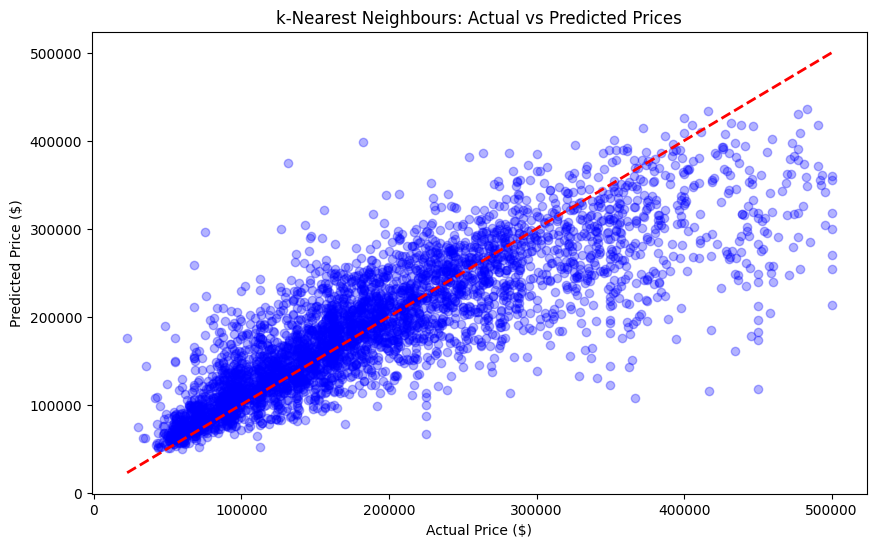

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(yTest, knnOptTestPred, alpha=0.3, color='blue')
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], '--r', linewidth=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('k-Nearest Neighbours: Actual vs Predicted Prices')
plt.show()

## Conclusion - Comparing Different Models

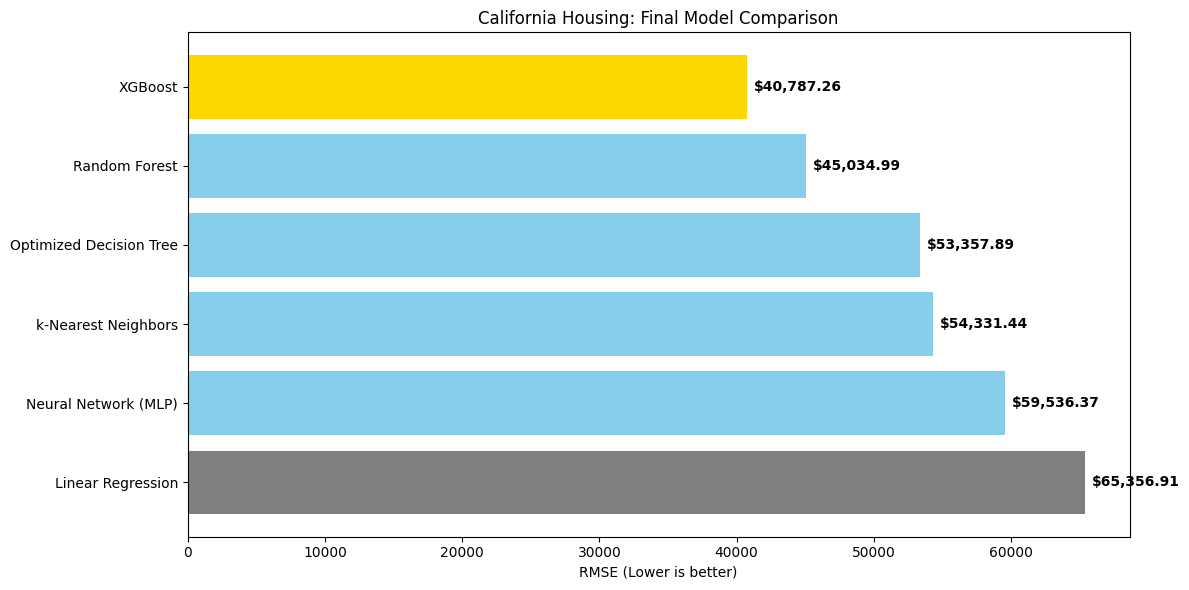

In [32]:
results={
    'Linear Regression': testLinRMSE,
    'Optimized Decision Tree': treeOptTestRMSE,
    'Random Forest': forestOptRmseTest,
    'XGBoost': xgbTestRmse,
    'Neural Network (MLP)': mlpTestRmse,
    'k-Nearest Neighbors': knnOptTestRMSE
}

sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(12, 6))
colors = ['gray' if (v > 60000) else 'skyblue' for v in sorted_results.values()]
colors[-1] = 'gold'

bars = plt.barh(list(sorted_results.keys()), list(sorted_results.values()), color=colors)
plt.xlabel('RMSE (Lower is better)')
plt.title('California Housing: Final Model Comparison')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2, f'${width:,.2f}',
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

As we can see, the XGBoost model yielded the best results. It improved the RMSE by over a third when compared to the baseline model (linear regression). The simpler models (k-Nearest Neighbours and Decision Tree) gave out a similar result of around `$54,000`, which is better than the baseline by over `$10,000`. Models based on the ensamble of decision trees performed the best, achieving RMSE below `$50,000`.